In [2]:
import os

import numpy as np
import time
from time import gmtime, strftime

from keras.models import load_model
import keras
from keras import backend as K
from keras.models import Sequential
from keras.models import Model
from keras.callbacks import History 
from keras.callbacks import ModelCheckpoint 


from PIL import Image
# from keras.preprocessing import image
# from IPython.display import display

# import tensorflow as tf

from keras.layers import Activation
from keras.layers.core import Dense, Flatten
from keras.optimizers import Adam
from keras.metrics import categorical_crossentropy
from keras.preprocessing.image import ImageDataGenerator
from keras.layers.normalization import BatchNormalization
from keras.layers.convolutional import *
from keras.applications import imagenet_utils
from sklearn.metrics import confusion_matrix
import itertools
import matplotlib.pyplot as plt

from keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img

%matplotlib inline

Using TensorFlow backend.


## Some Plotting functions

In [3]:
def plots(ims, figsize=(20,10), rows=1, interp=False, titles=None):
    if type(ims[0]) is np.ndarray:
        ims = np.array(ims).astype(np.uint8)
        if (ims.shape[-1] != 3):
            ims = ims.transpose((0,2,3,1))
    f = plt.figure(figsize=figsize)
    cols = len(ims)//rows if len(ims) % 2 == 0 else len(ims)//rows + 1
    for i in range(len(ims)):
        sp = f.add_subplot(rows, cols, i+1)
        sp.axis('Off')
        if titles is not None:
            sp.set_title(titles[i], fontsize=16)
        plt.imshow(ims[i], interpolation=None if interp else 'none')

In [4]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')



### Why Convolutional Neural Networks?

### Importing the data
The dataset consist out of 300 photo's taken on a white background, link: 
https://github.com/szindel/IkeaSchroeven.git
photos are taken from different angles, distributed uniformly on a white background(!). split: 4/6, 1/6, 1/6

Some values for the data augmentation are specified and 3 ImageDataGenerator objects are initialized.
These objects are in essence iterators, every time one is called it makes a new batch of vBatchsize augmented images

In [5]:
# train_path = '/train'
# test_path = '/home/szindel/Documents/IkeaSchroeven/Dataset_schroeven_raw_3/'
# valid_path = '/home/szindel/Documents/IkeaSchroeven/Dataset_schroeven_raw_3/valid'

# Path = "/home/szindel/Documents/IkeaSchroeven/"
Path = ""
Dataset = "Dataset_schroeven_raw_3"


#augmentation variables
vRotation = 360.
vHeightShift = 0.1
vWidthShift = 0.1
vChannelShift = 20.
bHorizontalFlip = True
bVerticalFlip = True
tBrightness = [0.8, 1.2]
vBatchSize = 25

#data iterators
train_batches_plot = ImageDataGenerator(
    rotation_range=vRotation, height_shift_range=vHeightShift, width_shift_range=vWidthShift, channel_shift_range = vChannelShift,
    horizontal_flip = bHorizontalFlip, vertical_flip = bVerticalFlip, brightness_range = tBrightness).flow_from_directory(
    Path+Dataset+"/train", target_size=(224,224), batch_size = 3)

train_batches = ImageDataGenerator(
    preprocessing_function=keras.applications.mobilenet.preprocess_input,
    rotation_range=vRotation, height_shift_range=vHeightShift, width_shift_range=vWidthShift, channel_shift_range = vChannelShift,
    horizontal_flip = bHorizontalFlip, vertical_flip = bVerticalFlip, brightness_range = tBrightness).flow_from_directory(
    Path+Dataset+"/train", target_size=(224,224), batch_size = vBatchSize)

valid_batches = ImageDataGenerator(
    preprocessing_function=keras.applications.mobilenet.preprocess_input, 
    rotation_range=vRotation, height_shift_range=vHeightShift, width_shift_range=vWidthShift, channel_shift_range = vChannelShift,
    horizontal_flip = bHorizontalFlip, vertical_flip = bVerticalFlip, brightness_range = tBrightness).flow_from_directory(
    Path+Dataset+"/valid", target_size=(224,224), batch_size = vBatchSize)

test_batches = ImageDataGenerator(
    preprocessing_function=keras.applications.mobilenet.preprocess_input,
    rotation_range=vRotation, height_shift_range=vHeightShift, width_shift_range=vWidthShift, channel_shift_range = vChannelShift,
    horizontal_flip = bHorizontalFlip, vertical_flip = bVerticalFlip, brightness_range = tBrightness).flow_from_directory(
    Path+Dataset+"/test", target_size=(224,224), batch_size = 10, shuffle = False)

Found 200 images belonging to 10 classes.
Found 200 images belonging to 10 classes.
Found 50 images belonging to 10 classes.
Found 50 images belonging to 10 classes.


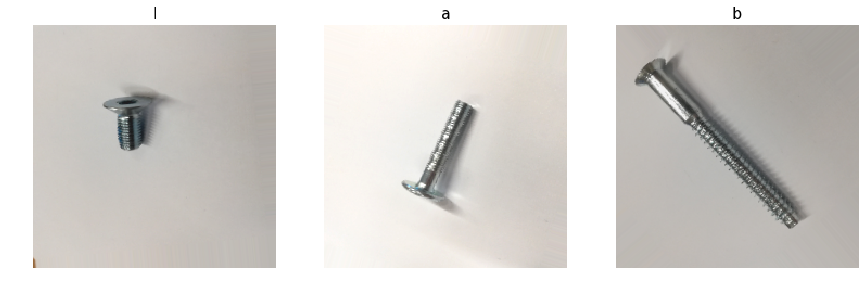

In [6]:
img, label = next(train_batches_plot)
plots(img, titles = 'label')

### Models used for testing:
Two versions of mobilenet and a version of VGG16

VGG16: Winner of ImageNet2015, image classification/segmentation competition, 1000 image classes.
mobileNet: Light weight, fast CNN's. Main goal to trade a bit in accuracy (0.5% less than VGG16) but massively gain in (training) speed. VGG16 needs signigicant more data+epochs to train to a high accuracy. MobileNets designed for industry applications: RealTime image classification for cars etc.


In [7]:
# mobileNet = keras.applications.mobilenet.MobileNet()
# VGG16 = keras.applications.vgg16.VGG16();
mobileNetV2 = keras.applications.mobilenet_v2.MobileNetV2()

#https://eli.thegreenplace.net/2018/depthwise-separable-convolutions-for-machine-learning/
#https://medium.freecodecamp.org/an-intuitive-guide-to-convolutional-neural-networks-260c2de0a050

In [8]:
x = mobileNetV2.layers[-2].output
predictions = Dense(10, activation='softmax')(x)
mymodel = Model(inputs = mobileNetV2.input, output = predictions)
mymodel.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ["accuracy"])
mymodel.save('MobileNetV2Model.h5')

/anaconda3/envs/ikea2/lib/python3.6/site-packages/ipykernel_launcher.py:3: UserWarning: Update your `Model` call to the Keras 2 API: `Model(inputs=Tensor("in..., outputs=Tensor("de...)`
  This is separate from the ipykernel package so we can avoid doing imports until


In [9]:
mymodel.summary()

__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            (None, 224, 224, 3)  0                                            
__________________________________________________________________________________________________
Conv1_pad (ZeroPadding2D)       (None, 225, 225, 3)  0           input_1[0][0]                    
__________________________________________________________________________________________________
Conv1 (Conv2D)                  (None, 112, 112, 32) 864         Conv1_pad[0][0]                  
__________________________________________________________________________________________________
bn_Conv1 (BatchNormalization)   (None, 112, 112, 32) 128         Conv1[0][0]                      
__________________________________________________________________________________________________
Conv1_relu

In [10]:
def GridSearchModel(LayerToTrain, model_loc, vEpochs = 20, vStepsEpoch = 5, vValidation_steps = 2 ,
                    outputfile="output_GridSearch", save_model = False):
    
    model = load_model(model_loc)
#     mobileNet = keras.applications.mobilenet.MobileNet()
#     x = mobileNet.layers[-6].output
#     predictions = Dense(10, activation='softmax')(x)
#     model_1 = Model(inputs = mobileNet.input, output = predictions)

    for layer in model.layers:
        layer.trainable = True
    if LayerToTrain != "all":
        for layer in model.layers[:-LayerToTrain]:
            layer.trainable = False
    
    start_time = time.time()
    
    if save_model == True:
        if not os.path.exists(outputfile):
            os.mkdir(outputfile)
            print("Directory " , outputfile ,  " Created ")
        else:    
            print("Directory " , outputfile ,  " already exists")
        #Python cant create a folder+subfolder so done in two steps.

        outputFolder = outputfile+"/Layer_"+str(LayerToTrain)
        if not os.path.exists(outputFolder):
            os.mkdir(outputFolder)
            print("Sub-Directory " , outputFolder ,  " Created ")
        else:    
            print("Sub-Directory " , outputFolder ,  " already exists")


        checkpoint = ModelCheckpoint(outputFolder+"/"+"weights.{epoch:02d}-{val_acc:.4f}.hdf5", monitor='val_acc', verbose=1, save_best_only=True, mode='max')
        callbacks_list = [checkpoint]
        model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ["accuracy"])
        hist = model.fit_generator(train_batches, steps_per_epoch = vStepsEpoch, validation_data = valid_batches, validation_steps = vValidation_steps,
                              epochs = vEpochs, verbose = 1, callbacks=callbacks_list)
        
    else:
        model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ["accuracy"])
        hist = model.fit_generator(train_batches, steps_per_epoch = vStepsEpoch, validation_data = valid_batches, validation_steps = vValidation_steps,
                              epochs = vEpochs, verbose = 1)

    
    #code is alleen om weg te schrijven
    fileWrite = open(outputfile+".txt", "a")
    fileWrite.write("\n")
    fileWrite.write("==================== New Model, trained the last: "+str(LayerToTrain)+" layers, until layer: "+str(layer.name)+", start time: "+str(strftime("%m-%d %H:%M:%S", gmtime()))+" ====================")
    fileWrite.write("\n")
    fileWrite.write(str(hist.history))
    old_val_acc = 0
    i_epoch = 0
    epoch_max = 0
    for b in hist.history.get("val_acc"):
        i_epoch+=1
        if b > old_val_acc:
            old_val_acc = b
            epoch_max = i_epoch
            
    fileWrite.write("\n")
    fileWrite.write("\n")
    fileWrite.write("Maximum val_acc of: "+str(old_val_acc)+" found at epoch: "+str(epoch_max)+
                    ", corresponding loss: "+str(hist.history.get("loss")[epoch_max-1])+", acc: "+str(hist.history.get("acc")[epoch_max-1])+
                   ", val_loss: "+str(hist.history.get("val_loss")[epoch_max-1]))
    fileWrite.write("\n")
    fileWrite.write("Done in: "+str(time.time()-start_time)+" seconds")
    fileWrite.write("\n")
    fileWrite.write("\n")
    fileWrite.close()
    del model
    return

In [2]:
GridSearchModel(10, "MobileNetV2Model.h5", 5, 2, 2,"output_MobileNetV2Model_86layers", True)

NameError: name 'GridSearchModel' is not defined

## After gridSearchModel
Models are stored only when a higher val_acc is reached than the previous max. These models can be loaded and tested; The test is done by predict_generator, which calls test_batches an x (Steps) number of times. So test_batches gives batches of size 10, steps = 10, 10*10 = 100 test images (also augmented!)

In [11]:
model = load_model('/home/szindel/Documents/IkeaSchroevenClean/output_MobileNetV1_86Layers/Layer_86/weights.76-1.0000.hdf5')

#### Mind you: test batches is an iterator! The test_batches in predict_generator has to match the labels put in the confusion matrix! Run prediction over the whole test_batches and use .classes to get all labels in order! 

In [12]:
predictions = model.predict_generator(test_batches, steps = 5, verbose = 1)
predictions

5/5 [==============================] - 10s 2s/step


array([[9.99886751e-01, 2.39064407e-10, 5.35058042e-08, 9.19832455e-05,
        1.96482297e-09, 8.00494888e-08, 3.60639683e-06, 2.09896854e-07,
        7.42108874e-10, 1.72785585e-05],
       [9.99998569e-01, 2.10320077e-11, 1.42821768e-10, 1.11359316e-06,
        2.62844677e-11, 3.01684899e-10, 1.86663726e-07, 9.89733961e-10,
        5.27816575e-11, 9.11280722e-08],
       [1.00000000e+00, 1.25693640e-12, 1.67450932e-11, 7.15492388e-10,
        5.09588709e-14, 6.16886490e-12, 2.00985806e-09, 7.75281728e-10,
        5.24299950e-13, 2.46285814e-09],
       [9.99999642e-01, 2.01669046e-11, 3.78470949e-10, 3.53455192e-07,
        5.50289241e-12, 4.05323552e-10, 2.24811973e-08, 2.99510683e-09,
        2.12882299e-11, 1.11299556e-08],
       [1.00000000e+00, 6.11250738e-15, 2.21978441e-13, 4.06185835e-10,
        7.64804852e-15, 2.85977839e-13, 5.20019250e-10, 8.87847348e-12,
        9.90985265e-15, 1.00584792e-11],
       [4.41523984e-10, 9.99999881e-01, 1.33915198e-10, 1.43569781e-10,
   

In [13]:
predictions.argmax(axis=1)

array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 9, 3, 4, 4,
       4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 9, 7, 7, 9, 7, 8, 8, 8, 8,
       8, 9, 9, 9, 9, 9])

In [14]:
test_labels = test_batches.classes
print(test_labels)

[0 0 0 0 0 1 1 1 1 1 2 2 2 2 2 3 3 3 3 3 4 4 4 4 4 5 5 5 5 5 6 6 6 6 6 7 7
 7 7 7 8 8 8 8 8 9 9 9 9 9]


Confusion matrix, without normalization
[[5 0 0 0 0 0 0 0 0 0]
 [0 5 0 0 0 0 0 0 0 0]
 [0 0 5 0 0 0 0 0 0 0]
 [0 0 0 4 0 0 0 0 0 1]
 [0 0 0 0 5 0 0 0 0 0]
 [0 0 0 0 0 5 0 0 0 0]
 [0 0 0 0 0 0 5 0 0 0]
 [0 0 0 0 0 0 0 3 0 2]
 [0 0 0 0 0 0 0 0 5 0]
 [0 0 0 0 0 0 0 0 0 5]]


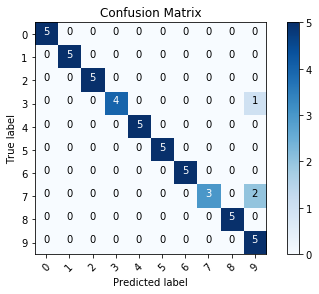

In [15]:
cm = confusion_matrix(test_labels, predictions.argmax(axis=1))
cm_plot_labels = ['0','1','2','3','4','5','6','7','8','9']
plot_confusion_matrix(cm, cm_plot_labels, title='Confusion Matrix')

In [16]:
test_batches_plot = ImageDataGenerator().flow_from_directory(
    Path+Dataset+"/test", target_size=(224,224), batch_size = 10, shuffle = False)

Found 50 images belonging to 10 classes.


In [17]:
img_list = []
label_list = []

for i in range(5):
    img, label = next(test_batches_plot)
    img_list.append(img[0])
    img_list.append(img[5])
    label_list.append(label[0])
    label_list.append(label[5])

/home/szindel/anaconda3/lib/python3.6/site-packages/matplotlib/text.py:1191: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if s != self._text:


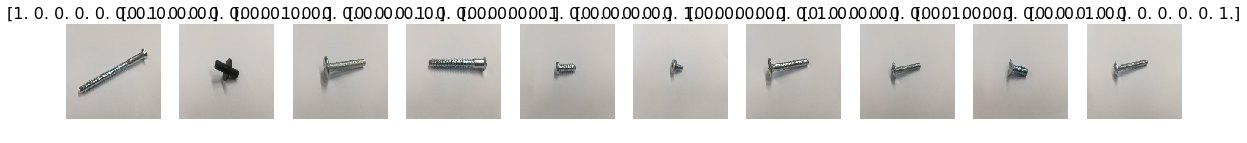

In [18]:
plots(img_list, titles = label_list)

In [19]:
img1 = load_img("_0_3857.jpg")
img2 = load_img("_0_8946.jpg")
img_arr1 = img_to_array(img1)
img_arr2 = img_to_array(img2)
img_arr1 = img_arr1.reshape((1,) + img_arr1.shape)
img_arr2 = img_arr2.reshape((1,) + img_arr2.shape)
img_arr1 = keras.applications.mobilenet.preprocess_input(img_arr1)
img_arr2 = keras.applications.mobilenet.preprocess_input(img_arr2)

In [25]:
predictions = model.predict(img_arr1)
predictions

array([[5.0203264e-01, 5.8324446e-07, 2.2132649e-07, 1.5072020e-04,
        7.5029538e-09, 8.0683890e-08, 4.1126019e-01, 8.4169017e-04,
        3.7851321e-06, 8.5710101e-02]], dtype=float32)

In [26]:
predictions.argmax(axis=1)

array([0])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


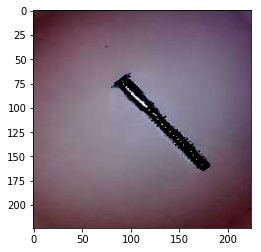

In [27]:
plt.imshow(img_arr1[0])

In [22]:
predictions = model.predict(img_arr2)
predictions.argmax(axis=1)

array([1])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


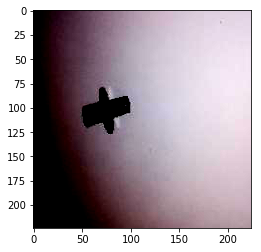

In [23]:
plt.imshow(img_arr2[0])

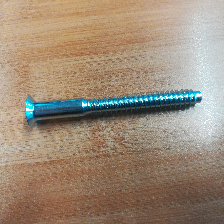

In [29]:
img4 = image.load_img("/home/szindel/Documents/IkeaSchroevenClean/Dataset_schroeven_raw_divers/IMG_20190108_134829.jpg", target_size=(224, 224))
img_arr4 = img_to_array(img4)
img_arr4 = img_arr4.reshape((1,) + img_arr4.shape)
img_arr4 = keras.applications.mobilenet.preprocess_input(img_arr4)
img4

In [30]:
predictions = model.predict(img_arr4)
predictions.argmax(axis=1)

array([0])

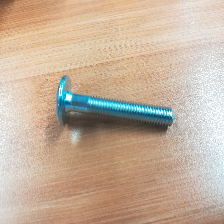

In [31]:
img5 = image.load_img("/home/szindel/Documents/IkeaSchroevenClean/Dataset_schroeven_raw_divers/IMG_20190110_134749.jpg", target_size=(224, 224))
img_arr5 = img_to_array(img5)
img_arr5 = img_arr5.reshape((1,) + img_arr5.shape)
img_arr5 = keras.applications.mobilenet.preprocess_input(img_arr5)
img5

In [32]:
predictions = model.predict(img_arr5)
predictions

array([[9.8922884e-01, 3.9377928e-09, 1.9457131e-08, 8.7215542e-04,
        3.0919511e-10, 1.4413253e-07, 9.6657230e-03, 2.1322525e-07,
        1.5088611e-06, 2.3138706e-04]], dtype=float32)

In [33]:
predictions.argmax(axis=1)

array([0])

In [37]:
modelV2 = load_model('/home/szindel/Documents/IkeaSchroevenClean/output_MobileNetV2Model/Layer_all/weights.87-0.9733.hdf5')

In [39]:
predictions = modelV2.predict(img_arr5)
predictions.argmax(axis=1)

array([0])